In [3]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from config import *

from lisaorbits import KeplerianOrbits, StaticConstellation
from lisaglitch import LPFLibraryGlitch
from scipy.signal import coherence

import warnings
warnings.filterwarnings("ignore")

In [1]:
import pytdi
print(pytdi.__version__)

1.3.1


In [12]:
def make_tdi_dict(X, Y, Z):
    A, E, T = get_AET(X, Y, Z)

    tdi_dict = {}
    channel_names = ['X', 'Y', 'Z', 'A', 'E', 'T']
    channel_data = [X, Y, Z, A, E, T]
    for i, name in enumerate(channel_names):
        psd_data = np.load(psd_path / f'psd_{name}.npz')
        f_psd, psd = psd_data['f_psd'], psd_data['psd']
        tdi_dict[name] = whiten_with_psd(channel_data[i], dt=0.25, f_psd=f_psd, psd=psd)
    return tdi_dict

In [30]:
#gw_dataset_path = '../dist/gw_ehm_dataset.h5'

with h5py.File(gw_lm_dataset_path, "r") as h5:
    X_array = h5["X"][:]       # shape (N, 512, 512)
    Y_array = h5["Y"][:]       # shape (N, 512, 512)
    Z_array = h5["Z"][:]       # shape (N, 512, 512)
    m1_array = h5["m1"][:]
    m2_array = h5["m2"][:]
    d_array = h5["d"][:]
    spin1_array = h5["spin1"][:]
    spin2_array = h5["spin2"][:]
    gw_beta_array = h5["gw_beta"][:]
    gw_lambda_array = h5["gw_lambda"][:]

In [27]:
index = 88  # Change this index to visualize different samples
m1 = m1_array[index]
m2 = m2_array[index]
d = d_array[index]
spin1 = spin1_array[index]
spin2 = spin2_array[index]
gw_beta = gw_beta_array[index]
gw_lambda = gw_lambda_array[index]

pipe = {'t0': 10368000, 'dt': 0.25,'size': 10 * 3600 / 0.25,
            't_inj': 5 * 3600}

gws = [{'type': 'BinaryInspiralGW', 'm1': m1, 'm2': m2, 'd': d,
        'spin1': spin1, 'spin2': spin2, 't_inj': pipe['t_inj'], 'domain': 'freq'}]

tdi_dict = make_tdi_dict(X_array[index], Y_array[index], Z_array[index])

specs = {'low_mass': {'trange':(-4, 1), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-4, 1), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-4, 2), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':6,
                       'drange':np.logspace(4, 5, 5)}}

chirp = chirp_mass(m1, m2)

if chirp < 1e5:
    spec = specs['low_mass']
elif chirp < 1e6:
    spec = specs['high_mass']
else:
    spec = specs['ext_high_mass']

In [28]:
event = gws[0]
channel = 'Y'
res = 256

start = time.time()
t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

3.9486289024353027


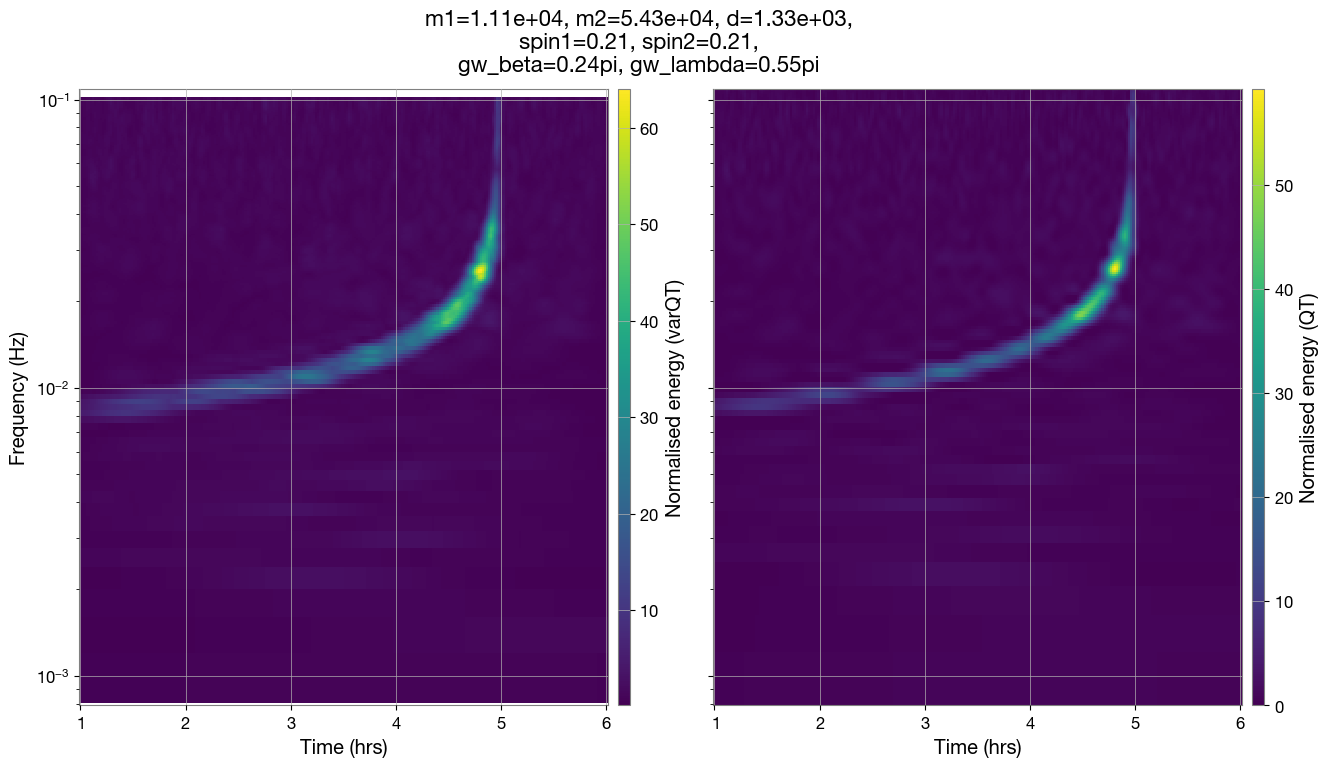

In [29]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15,8))
title = f'm1={m1:.2e}, m2={m2:.2e}, d={d:.2e}, \n' +\
    f'spin1={spin1:.2f}, spin2={spin2:.2f}, \n' +\
    f'gw_beta={gw_beta/np.pi:.2f}pi, gw_lambda={gw_lambda/np.pi:.2f}pi \n'
fig.suptitle(title, fontsize=16)

axes[0].pcolormesh(t_arr/3600, f_arr, varQT, cmap='viridis')
axes[1].pcolormesh(t_arr2/3600, f_arr2, QT, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].colorbar(label='Normalised energy (varQT)')
axes[1].colorbar(label='Normalised energy (QT)')
plt.show()

## The AET Channels

In [39]:
pipe = {'t0':10368000, 'dt':0.25, 'size':10*3600/0.25, 'gw_beta':0, 'gw_lambda':0}
    
glitches = [{'type':'OneSidedDoubleExpGlitch', 't_inj': 0,
            'level':0, 't_rise':1, 't_fall':1, 'inj_point':'readout_tmi_carrier_12'}]
gws = [{'type':'ReducedOneSidedDoubleExpGW', 't_inj': 0, 'amp':0, 't_rise':1, 't_fall':1}]

run_simulation(gws, glitches, pipe,
                gw_path, glitch_path, orbits_path,
                simulation_path,
                disable_noise=False)
tdi_dict = run_tdi(simulation_path, pipe)

X, Y, Z = tdi_dict['X'].value, tdi_dict['Y'].value, tdi_dict['Z'].value
A = (Z - X)/np.sqrt(2)
E = (X - 2*Y + Z)/np.sqrt(6)
T = (X + Y + Z)/np.sqrt(3)

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported


In [90]:
corrAET = np.corrcoef([A, E, T])
print('Correlation matrix for A, E, T:')
print(corrAET)

Correlation matrix for A, E, T:
[[ 1.          0.59346152  0.01185624]
 [ 0.59346152  1.         -0.00970604]
 [ 0.01185624 -0.00970604  1.        ]]


In [91]:
corrXYZ = np.corrcoef([X, Y, Z])
print('Correlation matrix for X, Y, Z:')
print(corrXYZ)

Correlation matrix for X, Y, Z:
[[ 1.         -0.45119783  0.37411981]
 [-0.45119783  1.         -0.79813184]
 [ 0.37411981 -0.79813184  1.        ]]


In [92]:
orb = h5py.File(orbits_path, "r")

x = orb['tcb/x'][:]
r1 = x[:,0,:]
r2 = x[:,1,:]
r3 = x[:,2,:]

L12 = np.linalg.norm(r1 - r2, axis=1)
L23 = np.linalg.norm(r2 - r3, axis=1)
L31 = np.linalg.norm(r3 - r1, axis=1)

print(f'L12: {L12[0]:.4e}')
print(f'L23: {L23[0]:.4e}')
print(f'L31: {L31[0]:.4e}')

L12: 2.4894e+09
L23: 2.4977e+09
L31: 2.4980e+09


In [88]:
dt = pipe['dt']
fs = 1 / dt  # sampling frequency

fTE, cohTE = coherence(
    T, E,
    fs=fs,
    nperseg=4e4,      # choose based on data length
    noverlap=2e4
)

fAE, cohAE = coherence(
    A, E,
    fs=fs,
    nperseg=4e4,      # choose based on data length
    noverlap=2e4
)

fAT, cohAT = coherence(
    A, T,
    fs=fs,
    nperseg=4e4,      # choose based on data length
    noverlap=2e4
)

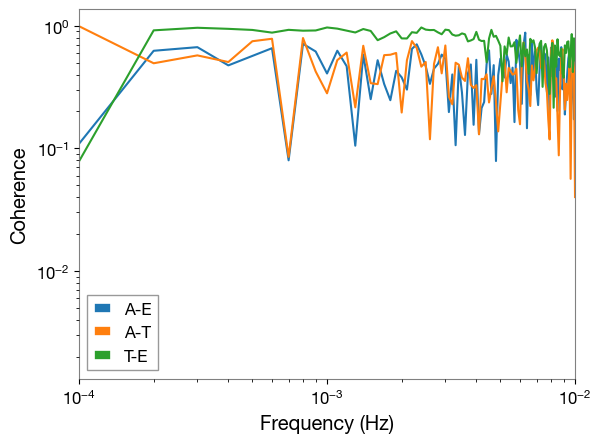

In [96]:
plt.loglog(fAE, np.sqrt(cohAE), label='A-E')
plt.loglog(fAT, np.sqrt(cohAT), label='A-T')
plt.loglog(fTE, np.sqrt(cohTE), label='T-E')
plt.xlim(1e-4, 1e-2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence')
plt.grid()
plt.legend()
plt.show()

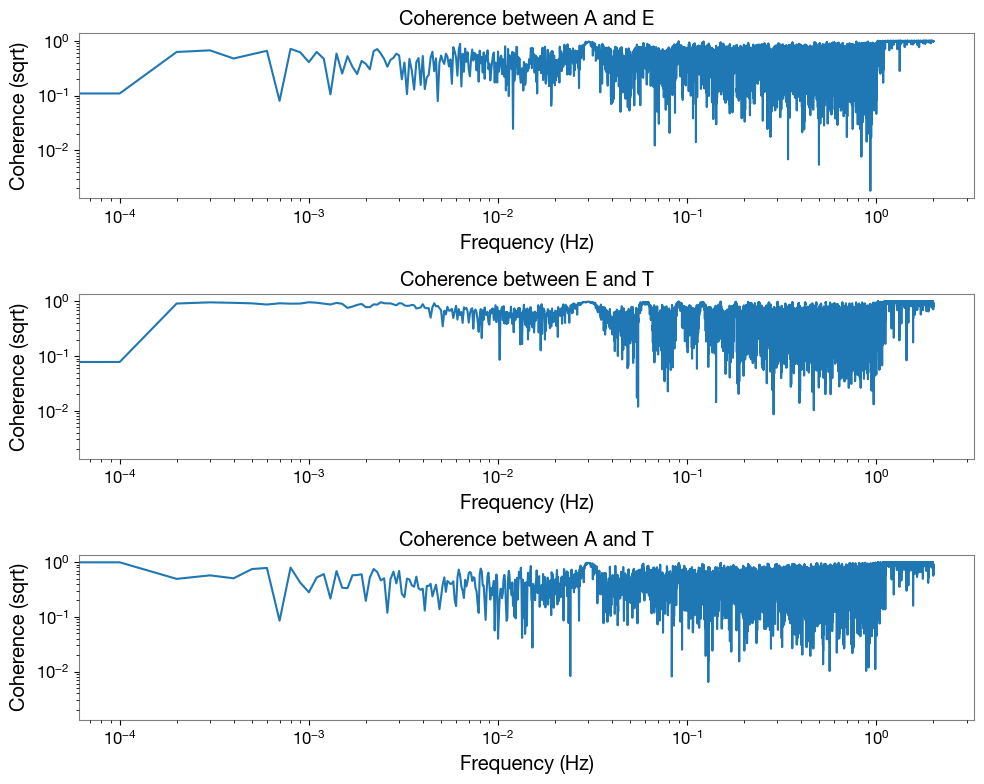

In [84]:
fig, axes = plt.subplots(3, 1, sharey=True, figsize=(10,8))

axes[0].loglog(fAE, np.sqrt(cohAE))
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Coherence (sqrt)')
axes[0].set_title('Coherence between A and E')
axes[0].grid()

axes[1].loglog(fTE, np.sqrt(cohTE))
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Coherence (sqrt)')
axes[1].set_title('Coherence between E and T')
axes[1].grid()

axes[2].loglog(fAT, np.sqrt(cohAT))
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Coherence (sqrt)')
axes[2].set_title('Coherence between A and T')
axes[2].grid()
plt.tight_layout()
plt.show()

## Orbits

In [43]:
orb = h5py.File(orbits_path, "r")

In [44]:
def print_tree(name, obj):
    print(name, type(obj))

orb.visititems(print_tree)

tcb <class 'h5py._hl.group.Group'>
tcb/a <class 'h5py._hl.dataset.Dataset'>
tcb/d_ltt <class 'h5py._hl.dataset.Dataset'>
tcb/d_ppr <class 'h5py._hl.dataset.Dataset'>
tcb/delta_tau <class 'h5py._hl.dataset.Dataset'>
tcb/ltt <class 'h5py._hl.dataset.Dataset'>
tcb/n <class 'h5py._hl.dataset.Dataset'>
tcb/ppr <class 'h5py._hl.dataset.Dataset'>
tcb/v <class 'h5py._hl.dataset.Dataset'>
tcb/x <class 'h5py._hl.dataset.Dataset'>
tps <class 'h5py._hl.group.Group'>
tps/d_ppr <class 'h5py._hl.dataset.Dataset'>
tps/delta_t <class 'h5py._hl.dataset.Dataset'>
tps/ppr <class 'h5py._hl.dataset.Dataset'>


In [45]:
x = orb['tcb/x'][:]
r1 = x[:,0,:]
r2 = x[:,1,:]
r3 = x[:,2,:]

In [76]:
L12 = np.linalg.norm(r1 - r2, axis=1)
L23 = np.linalg.norm(r2 - r3, axis=1)
L31 = np.linalg.norm(r3 - r1, axis=1)

print(f'L12: {L12[0]:.4e}')
print(f'L23: {L23[0]:.4e}')
print(f'L31: {L31[0]:.4e}')

L12: 2.4894e+09
L23: 2.4977e+09
L31: 2.4980e+09


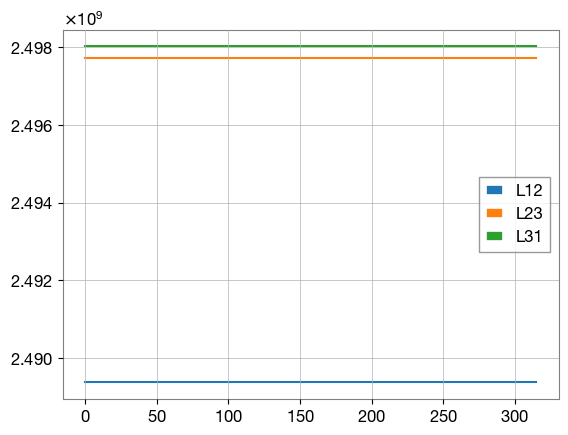

In [47]:
plt.plot(L12, label="L12")
plt.plot(L23, label="L23")
plt.plot(L31, label="L31")
plt.legend()
plt.show()